## STEP 1: Setup & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


In [ ]:
!pip install -q tensorflow>=2.8.0 scikit-learn matplotlib seaborn

In [ ]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split

# ── STEP 1: Kumpulkan semua gambar dari semua versi ─────────────────
DATASET_PATHS = [
    "/content/drive/MyDrive/Colab Notebooks/Dataset/Phase Your Moon.v6i.multiclass",
    "/content/drive/MyDrive/Colab Notebooks/Dataset/Phase Your Moon.v7i.multiclass",
    "/content/drive/MyDrive/Colab Notebooks/Dataset/Phase Your Moon.v8i.multiclass",
    "/content/drive/MyDrive/Colab Notebooks/Dataset/Phase Your Moon.v9i.multiclass",
    "/content/drive/MyDrive/Colab Notebooks/Dataset/Phase Your Moon.v10i.multiclass",
    "/content/drive/MyDrive/Colab Notebooks/Dataset/Phase Your Moon.v11i.multiclass"
]

FIXED_CLASS_NAMES = [
    'First_Quarter_Moon', 'Full_Moon', 'New_Moon',
    'Third_Quarter_Moon', 'Waning_Gibbous_Moon',
    'Wanning_Cresent_Moon', 'Waxing_Cresent_Moon', 'Waxing_Gibbous_Moon'
]

OUTPUT_DATASET = "/content/drive/MyDrive/Colab Notebooks/Dataset/MoonPhase_Combined6_Clean_Dataset"


all_images = []
seen_hashes = set()
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("Collecting all images...")
for ds_path in DATASET_PATHS:
    for split in ['train', 'valid', 'test']:
        split_path = os.path.join(ds_path, split)
        if not os.path.exists(split_path):
            continue
        for cls in FIXED_CLASS_NAMES:
            cls_path = os.path.join(split_path, cls)
            if not os.path.exists(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if not fname.lower().endswith(('.jpg','.jpeg','.png')):
                    continue
                fpath = os.path.join(cls_path, fname)
                h = file_hash(fpath)
                if h in seen_hashes:
                    continue
                seen_hashes.add(h)
                all_images.append((fpath, cls))

print(f"Total unique images: {len(all_images)}")
for cls in FIXED_CLASS_NAMES:
    count = sum(1 for _, c in all_images if c == cls)
    print(f"  {cls}: {count}")

# ── STEP 2: Stratified Split 70/20/10 ───────────────────────────────
filepaths = [x[0] for x in all_images]
labels    = [x[1] for x in all_images]

# Split pertama: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    filepaths, labels,
    test_size=0.30,
    stratify=labels,   # ✅ stratified: proporsi kelas sama di semua split
    random_state=42
)

# Split kedua: dari 30% temp → 20% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.333,   # 0.333 × 0.30 = 0.10 dari total
    stratify=y_temp,
    random_state=42
)

print(f"\n✅ Final split:")
print(f"   Train : {len(X_train)} ({len(X_train)/len(all_images)*100:.1f}%)")
print(f"   Val   : {len(X_val)}   ({len(X_val)/len(all_images)*100:.1f}%)")
print(f"   Test  : {len(X_test)}  ({len(X_test)/len(all_images)*100:.1f}%)")

# ── STEP 3: Copy ke struktur folder baru ────────────────────────────
for split_name, paths, lbls in [
    ('train', X_train, y_train),
    ('valid', X_val,   y_val),
    ('test',  X_test,  y_test)
]:
    for fpath, cls in zip(paths, lbls):
        dst_dir = os.path.join(OUTPUT_DATASET, split_name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(fpath, os.path.join(dst_dir, os.path.basename(fpath)))

print("\n✅ Dataset clean berhasil dibuat!")
print(f"   Lokasi: {OUTPUT_DATASET}")

Total unique images: 2905
  First_Quarter_Moon: 369
  Full_Moon: 411
  New_Moon: 327
  Third_Quarter_Moon: 373
  Waning_Gibbous_Moon: 346
  Wanning_Cresent_Moon: 364
  Waxing_Cresent_Moon: 369
  Waxing_Gibbous_Moon: 346

✅ Final split:
   Train : 2033 (70.0%)
   Val   : 581   (20.0%)
   Test  : 291  (10.0%)

✅ Dataset clean berhasil dibuat!
   Lokasi: /content/drive/MyDrive/Colab Notebooks/Dataset/MoonPhase_Combined6_Clean_Dataset


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS_PHASE1 = 30
EPOCHS_PHASE2 = 30
EPOCHS_PHASE3 = 20

# ✅ Setelah re-split: ganti ke satu dataset yang sudah bersih
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Dataset/MoonPhase_Combined6_Clean_Dataset"


FIXED_CLASS_NAMES = [
    'First_Quarter_Moon', 'Full_Moon', 'New_Moon',
    'Third_Quarter_Moon', 'Waning_Gibbous_Moon',
    'Wanning_Cresent_Moon', 'Waxing_Cresent_Moon', 'Waxing_Gibbous_Moon'
]


##  STEP 2: Moon-Appropriate Augmentation

- Rotation: ±28° (moon-safe)
- Brightness/Contrast: ±15%
- Zoom ±15%

In [ ]:
def create_moon_aware_augmentation(strength: str = 'moderate') -> keras.Sequential:

    if strength == 'light':
        aug = keras.Sequential([
            layers.RandomRotation(0.03),          # ±5.4°
            layers.RandomZoom(0.08, 0.08),        # ±8%
            layers.RandomBrightness(0.08),        # ±8%
        ], name="augmentation_light")

    else:  # moderate
        aug = keras.Sequential([
            layers.RandomRotation(0.055),         # ±9.9°
            layers.RandomZoom(0.10, 0.10),        # ±10%
            layers.RandomTranslation(0.05, 0.05), # ±5%
            layers.RandomBrightness(0.10),        # ±10%
            layers.RandomContrast(0.10),          # ±10%
        ], name="augmentation_moderate")

    return aug

augmentation       = create_moon_aware_augmentation('moderate')
augmentation_light = create_moon_aware_augmentation('light')

print(f"\n Augmentation Phase 1 & 2 : moderate")
print(f" Augmentation Phase 3     : light)")
print(f"   Transforms P1&2: {[l.name for l in augmentation.layers]}")
print(f"   Transforms P3  : {[l.name for l in augmentation_light.layers]}")


 Augmentation Phase 1 & 2 : moderate
 Augmentation Phase 3     : light)
   Transforms P1&2: ['random_rotation', 'random_zoom', 'random_translation', 'random_brightness', 'random_contrast']
   Transforms P3  : ['random_rotation_1', 'random_zoom_1', 'random_brightness_1']


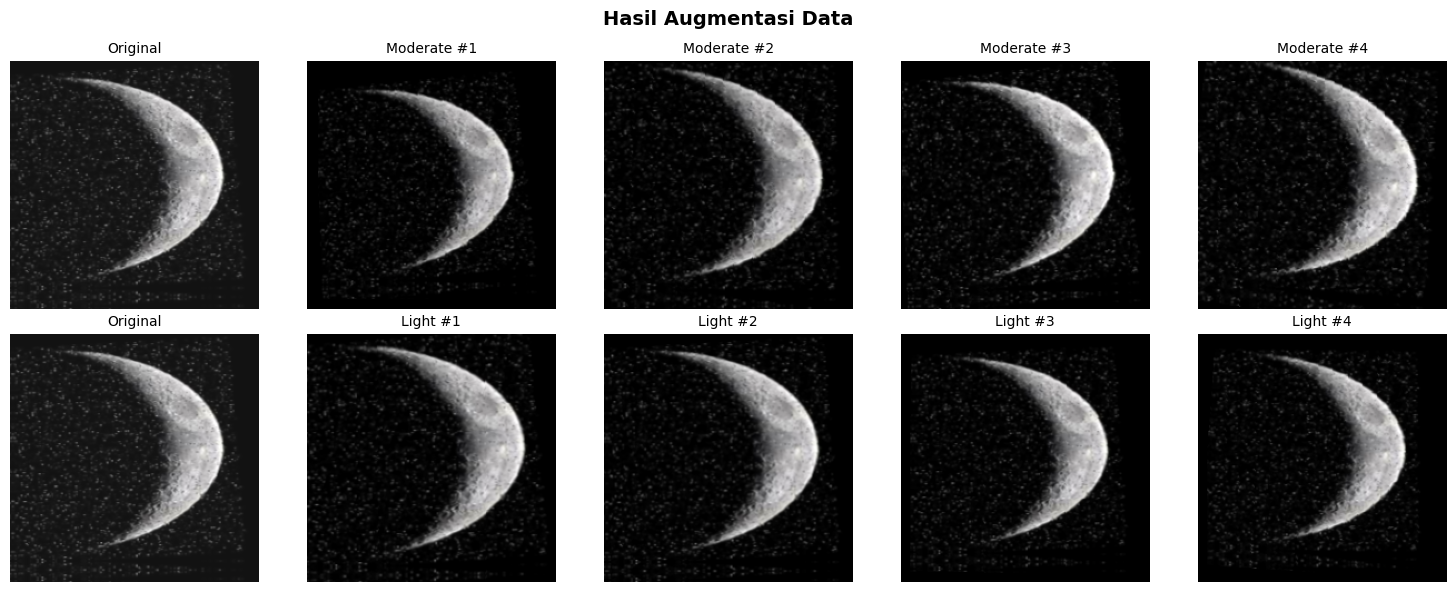

Saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Ambil 1 gambar sample
sample_batch = next(iter(train_ds))
sample_image = sample_batch[0][0].numpy()  # shape (224, 224, 3), range [-1, 1]

def denorm(img):
    img = (img + 1.0) / 2.0
    return np.clip(img, 0.0, 1.0)

def augment_moderate(img):
    """Manual augmentation tanpa Keras layer"""
    img = img.copy()
    # Random rotation ±10°
    angle = np.random.uniform(-10, 10)
    img_pil = tf.keras.preprocessing.image.array_to_img(denorm(img))
    from PIL import Image
    import PIL.ImageEnhance as IE
    img_pil = img_pil.rotate(angle)
    # Random brightness
    enhancer = IE.Brightness(img_pil)
    img_pil = enhancer.enhance(np.random.uniform(0.9, 1.1))
    # Random zoom (crop then resize)
    zoom = np.random.uniform(0.9, 1.1)
    w, h = img_pil.size
    new_w, new_h = int(w/zoom), int(h/zoom)
    left = (w - new_w) // 2
    top = (h - new_h) // 2
    img_pil = img_pil.crop((left, top, left+new_w, top+new_h))
    img_pil = img_pil.resize((224, 224), Image.BILINEAR)
    return np.array(img_pil) / 255.0

def augment_light(img):
    img = img.copy()
    angle = np.random.uniform(-5, 5)
    img_pil = tf.keras.preprocessing.image.array_to_img(denorm(img))
    from PIL import Image
    img_pil = img_pil.rotate(angle)
    zoom = np.random.uniform(0.92, 1.08)
    w, h = img_pil.size
    new_w, new_h = int(w/zoom), int(h/zoom)
    left = (w - new_w) // 2
    top = (h - new_h) // 2
    img_pil = img_pil.crop((left, top, left+new_w, top+new_h))
    img_pil = img_pil.resize((224, 224), Image.BILINEAR)
    return np.array(img_pil) / 255.0

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Hasil Augmentasi Data', fontsize=14, fontweight='bold')

# Baris 1: Moderate
axes[0][0].imshow(denorm(sample_image))
axes[0][0].set_title('Original', fontsize=10)
axes[0][0].axis('off')
for i in range(1, 5):
    axes[0][i].imshow(augment_moderate(sample_image))
    axes[0][i].set_title(f'Moderate #{i}', fontsize=10)
    axes[0][i].axis('off')

# Baris 2: Light
axes[1][0].imshow(denorm(sample_image))
axes[1][0].set_title('Original', fontsize=10)
axes[1][0].axis('off')
for i in range(1, 5):
    axes[1][i].imshow(augment_light(sample_image))
    axes[1][i].set_title(f'Light #{i}', fontsize=10)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('augmentation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

---
##  STEP 3: Load Dataset

In [ ]:
def create_clean_datasets():

    if not os.path.exists(DATASET_PATH):
        raise FileNotFoundError(f"Dataset path not found:\n{DATASET_PATH}")

    def compute_class_counts(split='train'):
        counts = {}
        split_path = os.path.join(DATASET_PATH, split)

        for cls in FIXED_CLASS_NAMES:
            cls_dir = os.path.join(split_path, cls)

            if os.path.exists(cls_dir):
                counts[cls] = len([
                    f for f in os.listdir(cls_dir)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ])
            else:
                counts[cls] = 0
        return counts

    class_counts = compute_class_counts('train')
    total = sum(class_counts.values())
    class_weight = {
        i: (total / (len(FIXED_CLASS_NAMES) * class_counts[cls]))
        if class_counts[cls] > 0 else 1.0
        for i, cls in enumerate(FIXED_CLASS_NAMES)
    }
    print("\n📊 Class Counts (Train)")
    for cls, count in class_counts.items():
        print(f"   {cls:<25}: {count}")

    print("\n⚖️ Class Weights")
    for i, w in class_weight.items():
        print(f"   {FIXED_CLASS_NAMES[i]:<25}: {w:.4f}")

    # -----------------------------------------------------
    # LOAD DATASETS
    # -----------------------------------------------------
    print("\n📂 Loading datasets...")

    train_ds_raw = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_PATH, 'train'),
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=FIXED_CLASS_NAMES,
        shuffle=True,
        seed=SEED,
        verbose=0
    )

    val_ds_raw = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_PATH, 'valid'),
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=FIXED_CLASS_NAMES,
        shuffle=False,
        verbose=0
    )

    test_ds_raw = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_PATH, 'test'),
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=FIXED_CLASS_NAMES,
        shuffle=False,
        verbose=0
    )
    class_names = FIXED_CLASS_NAMES

    def preprocess_only(images, labels):
        images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
        return images, labels

    def augment_and_preprocess(images, labels):
        images = augmentation(images, training=True)
        images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
        return images, labels

    def augment_light_and_preprocess(images, labels):
        images = augmentation_light(images, training=True)
        images = tf.keras.applications.mobilenet_v2.preprocess_input(images)
        return images, labels

    # Pipeline Phase 1 & 2
    train_ds = train_ds_raw.map(augment_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds   = val_ds_raw.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds  = test_ds_raw.map(preprocess_only, num_parallel_calls=tf.data.AUTOTUNE)

    # Pipeline Phase 3
    global train_ds_p3
    train_ds_p3 = train_ds_raw.map(augment_light_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)


    train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
    val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)
    test_ds  = test_ds.cache().prefetch(tf.data.AUTOTUNE)
    train_ds_p3 = train_ds_p3.cache().prefetch(tf.data.AUTOTUNE)

    # -----------------------------------------------------
    # DATASET STATISTICS
    # -----------------------------------------------------
    train_count = sum(class_counts.values())

    val_count = sum([
        len([
            f for f in os.listdir(
                os.path.join(DATASET_PATH, 'valid', cls)
            )
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for cls in FIXED_CLASS_NAMES
    ])

    test_count = sum([
        len([
            f for f in os.listdir(
                os.path.join(DATASET_PATH, 'test', cls)
            )
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        for cls in FIXED_CLASS_NAMES
    ])

    print("\n✅ Dataset Statistics")
    print(f"   Training   : {train_count} images")
    print(f"   Validation : {val_count} images")
    print(f"   Test       : {test_count} images")

    print("\n✅ Pipeline Ready")
    print("   train_ds     -> moderate augmentation")
    print("   train_ds_p3  -> light augmentation")
    print("   val_ds       -> preprocessing only")
    print("   test_ds      -> preprocessing only")

    print("\n" + "="*70)

    return (
        train_ds,
        val_ds,
        test_ds,
        train_ds_p3,
        FIXED_CLASS_NAMES,
        class_weight
    )

# =========================================================
# RUN
# =========================================================
train_ds, val_ds, test_ds, train_ds_p3, class_names, class_weight = create_clean_datasets()

num_classes = len(class_names)

print(f"\n✅ Number of classes: {num_classes}")
print(f"✅ Classes: {class_names}")



📊 Class Counts (Train)
   First_Quarter_Moon       : 258
   Full_Moon                : 288
   New_Moon                 : 229
   Third_Quarter_Moon       : 261
   Waning_Gibbous_Moon      : 242
   Wanning_Cresent_Moon     : 255
   Waxing_Cresent_Moon      : 258
   Waxing_Gibbous_Moon      : 242

⚖️ Class Weights
   First_Quarter_Moon       : 0.9850
   Full_Moon                : 0.8824
   New_Moon                 : 1.1097
   Third_Quarter_Moon       : 0.9737
   Waning_Gibbous_Moon      : 1.0501
   Wanning_Cresent_Moon     : 0.9966
   Waxing_Cresent_Moon      : 0.9850
   Waxing_Gibbous_Moon      : 1.0501

📂 Loading datasets...

✅ Dataset Statistics
   Training   : 2033 images
   Validation : 581 images
   Test       : 291 images

✅ Pipeline Ready
   train_ds     -> moderate augmentation
   train_ds_p3  -> light augmentation
   val_ds       -> preprocessing only
   test_ds      -> preprocessing only


✅ Number of classes: 8
✅ Classes: ['First_Quarter_Moon', 'Full_Moon', 'New_Moon', 'Third

---
##  STEP 4: Build Model (Standard Architecture)

In [ ]:
def create_clean_model(num_classes):
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="MoonPhase_MobileNetV2_3Phase")

    print(f"✅ Model: MobileNetV2 + Dense(256) head")
    print(f"   Total parameters: {model.count_params():,}")
    print(f"   Dropout: 0.20 + 0.15 | L2: 0.001")

    return model, base_model

model, base_model = create_clean_model(num_classes)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Model: MobileNetV2 + Dense(256) head
   Total parameters: 2,594,120
   Dropout: 0.20 + 0.15 | L2: 0.001


---
##  STEP 5: Compile Model (Standard Cross-Entropy)


In [ ]:

def cosine_schedule_p1(epoch, lr):
    return float(1e-3 * 0.5 * (1 + np.cos(np.pi * epoch / EPOCHS_PHASE1)))

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

model.summary()

best_model_path_p1 = os.path.join(OUTPUT_DIR, 'best_model_phase1.keras')

callbacks_p1 = [
    keras.callbacks.LearningRateScheduler(cosine_schedule_p1, verbose=0),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_model_path_p1, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    )
]

print(" Phase 1 configuration:")
print("   LR Schedule  : Cosine Annealing (1e-3 → ~0)")
print("   Loss         : CategoricalCrossentropy (label_smoothing=0.05)")
print("   EarlyStopping: val_accuracy, patience=12")
print(f"   Checkpoint   : {best_model_path_p1}")


Model: "MoonPhase_MobileNetV2_3Phase"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,120 (9.90 MB)

 Trainable params: 333,064 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

✅ Phase 1 configuration:
   LR Schedule  : Cosine Annealing (1e-3 → ~0)
   Loss         : CategoricalCrossentropy (label_smoothing=0.05)
   EarlyStopping: val_accuracy, patience=12
   Checkpoint   : /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase1.keras


---
##  STEP 6: Phase 1 - Feature Extraction (30 epochs)

**Strategy**: Train classification head only, freeze base model

In [ ]:
print("\n" + "="*70)
print("🧠 PHASE 1: FEATURE EXTRACTION")
print("="*70)
print(f"✅ Base model  : FROZEN")
print(f"✅ Augmentasi  : moderate")
print(f"✅ LR Schedule : Cosine Annealing")
print(f"✅ Epochs      : {EPOCHS_PHASE1}")
print("="*70 + "\n")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
    verbose=1,
    class_weight=class_weight
)

best_val_acc_p1  = max(history1.history['val_accuracy'])
best_val_loss_p1 = min(history1.history['val_loss'])

print("\n" + "="*70)
print(f"✅ PHASE 1 COMPLETE!")
print(f"   Best val accuracy : {best_val_acc_p1*100:.2f}%")
print(f"   Best val loss     : {best_val_loss_p1:.4f}")
print(f"   Final train acc   : {history1.history['accuracy'][-1]*100:.2f}%")
print("="*70)



🧠 PHASE 1: FEATURE EXTRACTION
✅ Base model  : FROZEN
✅ Augmentasi  : moderate
✅ LR Schedule : Cosine Annealing
✅ Epochs      : 30

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.5090 - loss: 2.1596 - top2_accuracy: 0.6997
Epoch 1: val_accuracy improved from None to 0.59897, saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase1.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 830s 13s/step - accuracy: 0.6183 - loss: 1.8001 - top2_accuracy: 0.8077 - val_accuracy: 0.5990 - val_loss: 1.6124 - val_top2_accuracy: 0.8365 - learning_rate: 0.0010
Epoch 2/30
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8564 - loss: 1.0973 - top2_accuracy: 0.9691
Epoch 2: val_accuracy improved from 0.59897 to 0.69191, saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNet

---
## 🔥 STEP 7: Phase 2 - Fine-tuning (20 epochs)

**Strategy**: Unfreeze top 20 layers of base model, fine-tune with lower LR

In [ ]:
print("\n" + "="*70)
print("🔥 PHASE 2: FINE-TUNING (20 layers)")
print("="*70)

# ✅ Mulai konservatif: 20 layer
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# ✅ Freeze semua BatchNorm
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
frozen_count    = sum(1 for l in base_model.layers if not l.trainable)
print(f"✅ Frozen    : {frozen_count} (termasuk semua BatchNorm)")
print(f"✅ Trainable : {trainable_count}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),  # ✅ lebih kecil dari 5e-5
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

best_model_path_p2 = os.path.join(OUTPUT_DIR, 'best_model_phase2.keras')
callbacks_p2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=12,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_model_path_p2, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    )
]

print(f"✅ LR    : 2e-5")
print(f"✅ Epochs: {EPOCHS_PHASE2}")
print("="*70 + "\n")

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
    verbose=1,
    class_weight=class_weight
)

best_val_acc_p2  = max(history2.history['val_accuracy'])
best_val_loss_p2 = min(history2.history['val_loss'])
print("\n" + "="*70)
print(f"✅ PHASE 2 COMPLETE! Best val accuracy: {best_val_acc_p2*100:.2f}%")
print("="*70)



🔥 PHASE 2: FINE-TUNING (20 layers)
✅ Frozen    : 141 (termasuk semua BatchNorm)
✅ Trainable : 13
✅ LR    : 2e-5
✅ Epochs: 30

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9968 - loss: 0.5515 - top2_accuracy: 1.0000
Epoch 1: val_accuracy improved from None to 0.82100, saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase2.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 292ms/step - accuracy: 0.9975 - loss: 0.5497 - top2_accuracy: 1.0000 - val_accuracy: 0.8210 - val_loss: 0.9555 - val_top2_accuracy: 0.9604
Epoch 2/30
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9988 - loss: 0.5398 - top2_accuracy: 1.0000
Epoch 2: val_accuracy did not improve from 0.82100
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9985 - loss: 0.5409 - top2_accuracy: 1.0000 - val_accuracy: 0.8158 - 

In [ ]:
print("\n" + "="*70)
print("🚀 PHASE 3: DEEP FINE-TUNING (70 layers)")
print("="*70)

# ✅ Unfreeze lebih dalam
base_model.trainable = True
for layer in base_model.layers[:-70]:
    layer.trainable = False

# ✅ Tetap freeze semua BN
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
frozen_count    = sum(1 for l in base_model.layers if not l.trainable)
print(f"✅ Frozen    : {frozen_count}")
print(f"✅ Trainable : {trainable_count}")
print(f"✅ Augmentasi: light (sinyal bersih untuk deep fine-tuning)")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # ✅ sangat kecil
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.03),
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2, name='top2_accuracy')]
)

best_model_path_p3 = os.path.join(OUTPUT_DIR, 'best_model_phase3.keras')
callbacks_p3 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_model_path_p3, monitor='val_accuracy',
        save_best_only=True, mode='max', verbose=1
    )
]

print(f"✅ LR    : 1e-5")
print(f"✅ Epochs: {EPOCHS_PHASE3}")
print("="*70 + "\n")

history3 = model.fit(
    train_ds_p3,          # ✅ augmentasi ringan
    validation_data=val_ds,
    epochs=EPOCHS_PHASE3,
    callbacks=callbacks_p3,
    verbose=1,
    class_weight=class_weight
)

best_val_acc_p3  = max(history3.history['val_accuracy'])
best_val_loss_p3 = min(history3.history['val_loss'])
print("\n" + "="*70)
print(f"✅ PHASE 3 COMPLETE! Best val accuracy: {best_val_acc_p3*100:.2f}%")
print(f"   Best overall: {max(best_val_acc_p1, best_val_acc_p2, best_val_acc_p3)*100:.2f}%")
print("="*70)



🚀 PHASE 3: DEEP FINE-TUNING (70 layers)
✅ Frozen    : 141
✅ Trainable : 13
✅ Augmentasi: light (sinyal bersih untuk deep fine-tuning)
✅ LR    : 1e-5
✅ Epochs: 20

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9233 - loss: 0.6247 - top2_accuracy: 0.9841
Epoch 1: val_accuracy improved from None to 0.88812, saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/best_model_phase3.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 562ms/step - accuracy: 0.9247 - loss: 0.6215 - top2_accuracy: 0.9803 - val_accuracy: 0.8881 - val_loss: 0.7236 - val_top2_accuracy: 0.9759
Epoch 2/20
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9481 - loss: 0.5646 - top2_accuracy: 0.9888
Epoch 2: val_accuracy did not improve from 0.88812
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9415 - loss: 0.5740 - top2_accur

📊 Training history saved: training_history_3phase.png


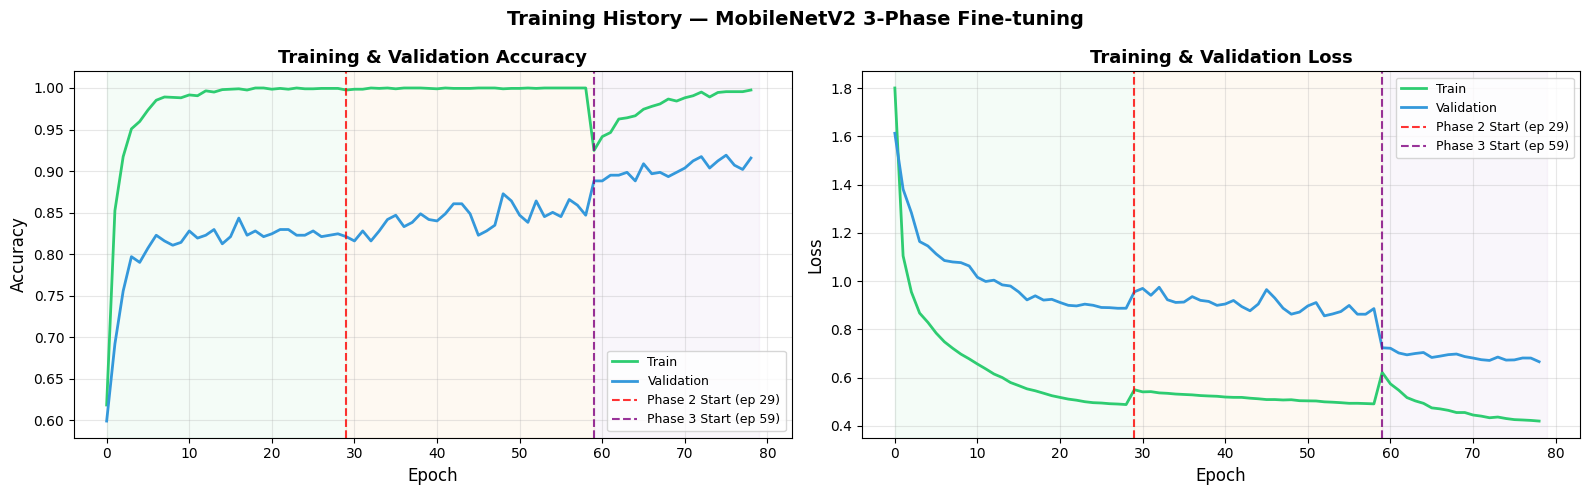


📈 Training Summary:
   Phase 1 (Feature Extraction, 29 ep)  : 84.34%
   Phase 2 (Fine-tune 20L, 30 ep)   : 87.26%
   Phase 3 (Deep FT 70L, 20 ep)    : 91.91%
   Best Overall                             : 91.91%


In [ ]:
# ✅ Combine semua 3 histories
history_combined = {
    'accuracy'    : history1.history['accuracy']     + history2.history['accuracy']     + history3.history['accuracy'],
    'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy'],
    'loss'        : history1.history['loss']          + history2.history['loss']          + history3.history['loss'],
    'val_loss'    : history1.history['val_loss']      + history2.history['val_loss']      + history3.history['val_loss'],
}

ep1 = len(history1.history['accuracy'])
ep2 = ep1 + len(history2.history['accuracy'])
total_epochs = len(history_combined['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History — MobileNetV2 3-Phase Fine-tuning', fontsize=14, fontweight='bold')

for ax, (train_key, val_key), title in zip(
    axes,
    [('accuracy','val_accuracy'), ('loss','val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history_combined[train_key], label='Train',      linewidth=2, color='#2ecc71')
    ax.plot(history_combined[val_key],   label='Validation', linewidth=2, color='#3498db')

    ax.axvline(x=ep1, color='red',    linestyle='--', alpha=0.8, label=f'Phase 2 Start (ep {ep1})')
    ax.axvline(x=ep2, color='purple', linestyle='--', alpha=0.8, label=f'Phase 3 Start (ep {ep2})')

    ax.axvspan(0,          ep1,          alpha=0.05, color='#2ecc71')
    ax.axvspan(ep1,        ep2,          alpha=0.05, color='#f39c12')
    ax.axvspan(ep2,        total_epochs, alpha=0.05, color='#9b59b6')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel(title,   fontsize=12)
    ax.set_title(f'Training & Validation {title}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_3phase.png', dpi=300, bbox_inches='tight')
print("📊 Training history saved: training_history_3phase.png")
plt.show()

print(f"\n📈 Training Summary:")
print(f"   Phase 1 (Feature Extraction, {ep1} ep)  : {best_val_acc_p1*100:.2f}%")
print(f"   Phase 2 (Fine-tune 20L, {ep2-ep1} ep)   : {best_val_acc_p2*100:.2f}%")
print(f"   Phase 3 (Deep FT 70L, {total_epochs-ep2} ep)    : {best_val_acc_p3*100:.2f}%")
print(f"   Best Overall                             : {max(best_val_acc_p1, best_val_acc_p2, best_val_acc_p3)*100:.2f}%")



In [ ]:
print("\n" + "="*70)
print("📈 TEST SET EVALUATION")
print("="*70)

# ✅ Load model terbaik otomatis dari 3 phase
best_accs = {
    'phase1': (best_val_acc_p1, best_model_path_p1),
    'phase2': (best_val_acc_p2, best_model_path_p2),
    'phase3': (best_val_acc_p3, best_model_path_p3),
}
best_phase = max(best_accs, key=lambda k: best_accs[k][0])
best_acc_val, best_overall_path = best_accs[best_phase]

model = keras.models.load_model(best_overall_path)
print(f"✅ Loaded: {os.path.basename(best_overall_path)} (best from {best_phase})")

test_loss, test_acc, test_top2 = model.evaluate(test_ds, verbose=1)

print("\n" + "="*70)
print("📊 TEST RESULTS")
print("="*70)
print(f"✅ Test Accuracy  : {test_acc*100:.2f}%")
print(f"✅ Test Top-2 Acc : {test_top2*100:.2f}%")
print(f"✅ Test Loss      : {test_loss:.4f}")

if test_acc >= 0.90:
    print(f"\n🎉 TARGET 90% TERCAPAI!")
elif test_acc >= 0.85:
    print(f"\n✅ EXCELLENT! {test_acc*100:.1f}% — sangat dekat target 90%")
elif test_acc >= 0.75:
    print(f"\n⚡ GOOD: {test_acc*100:.1f}% — pertimbangkan ensemble")
else:
    print(f"\n⚠️  Perlu optimasi lanjutan")
print("="*70)



📈 TEST SET EVALUATION
✅ Loaded: best_model_phase3.keras (best from phase3)
10/10 ━━━━━━━━━━━━━━━━━━━━ 103s 9s/step - accuracy: 0.8832 - loss: 0.7681 - top2_accuracy: 0.9691

📊 TEST RESULTS
✅ Test Accuracy  : 88.32%
✅ Test Top-2 Acc : 96.91%
✅ Test Loss      : 0.7681

✅ EXCELLENT! 88.3% — sangat dekat target 90%


---
## 🔍 STEP 10: Confusion Matrix & Per-Class Analysis


🔍 GENERATING PREDICTIONS FOR CONFUSION MATRIX

📊 CLASSIFICATION REPORT
                      precision    recall  f1-score   support

  First_Quarter_Moon       0.91      0.86      0.89        37
           Full_Moon       0.80      0.80      0.80        41
            New_Moon       0.93      0.82      0.87        33
  Third_Quarter_Moon       1.00      0.86      0.93        37
 Waning_Gibbous_Moon       0.82      0.91      0.86        35
Wanning_Cresent_Moon       0.90      1.00      0.95        36
 Waxing_Cresent_Moon       0.90      0.95      0.92        37
 Waxing_Gibbous_Moon       0.83      0.86      0.85        35

            accuracy                           0.88       291
           macro avg       0.89      0.88      0.88       291
        weighted avg       0.89      0.88      0.88       291


⚠️  Classes needing attention (recall < 50%):

📊 Confusion matrix saved: confusion_matrix_clean.png


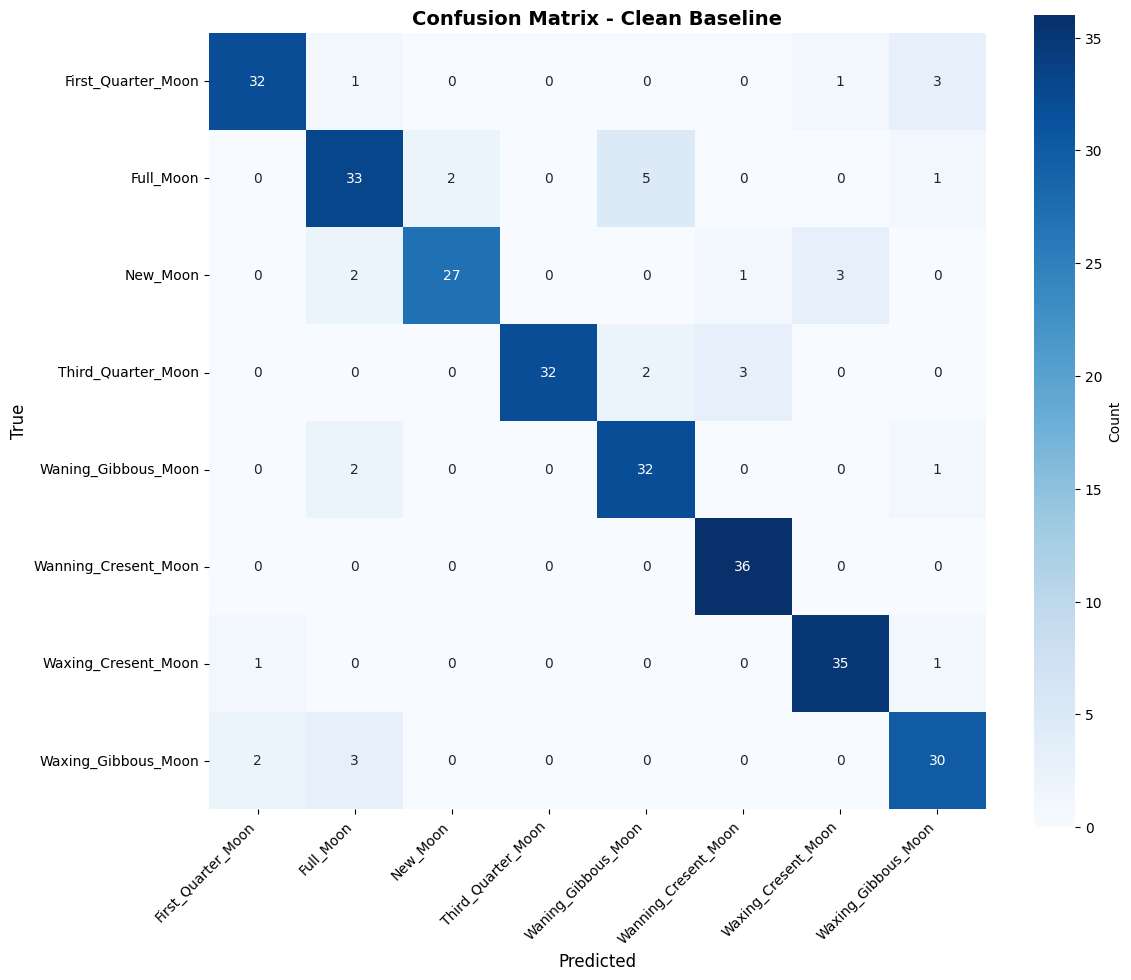

In [ ]:
print("\n" + "="*70)
print("🔍 GENERATING PREDICTIONS FOR CONFUSION MATRIX")
print("="*70)

# Generate predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
print(report)

# Identify weak classes
print("\n⚠️  Classes needing attention (recall < 50%):")
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
for class_name in class_names:
    recall = report_dict[class_name]['recall']
    if recall < 0.5:
        support = report_dict[class_name]['support']
        print(f"   ❌ {class_name}: {recall*100:.1f}% recall ({int(support)} samples)")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'},
    square=True
)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix - Clean Baseline', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix_clean.png', dpi=300, bbox_inches='tight')
print("\n📊 Confusion matrix saved: confusion_matrix_clean.png")
plt.show()


🧪 TESTING INFERENCE DENGAN SAMPLING LEBIH BERAGAM
✅ Model loaded: best_model_phase3.keras

📊 Predictions (lebih beragam kelas):
1. ✅
   Predicted: First_Quarter_Moon (76.46%)
   True: First_Quarter_Moon
2. ✅
   Predicted: First_Quarter_Moon (97.31%)
   True: First_Quarter_Moon
3. ✅
   Predicted: Full_Moon (90.69%)
   True: Full_Moon
4. ✅
   Predicted: Full_Moon (87.88%)
   True: Full_Moon
5. ✅
   Predicted: New_Moon (91.43%)
   True: New_Moon
6. ✅
   Predicted: New_Moon (64.05%)
   True: New_Moon
7. ✅
   Predicted: Third_Quarter_Moon (78.72%)
   True: Third_Quarter_Moon
8. ✅
   Predicted: Third_Quarter_Moon (97.26%)
   True: Third_Quarter_Moon
9. ✅
   Predicted: Waning_Gibbous_Moon (70.63%)
   True: Waning_Gibbous_Moon
10. ✅
   Predicted: Waning_Gibbous_Moon (52.60%)
   True: Waning_Gibbous_Moon
11. ✅
   Predicted: Wanning_Cresent_Moon (99.06%)
   True: Wanning_Cresent_Moon
12. ✅
   Predicted: Wanning_Cresent_Moon (94.88%)
   True: Wanning_Cresent_Moon
13. ✅
   Predicted: Waxing_Crese

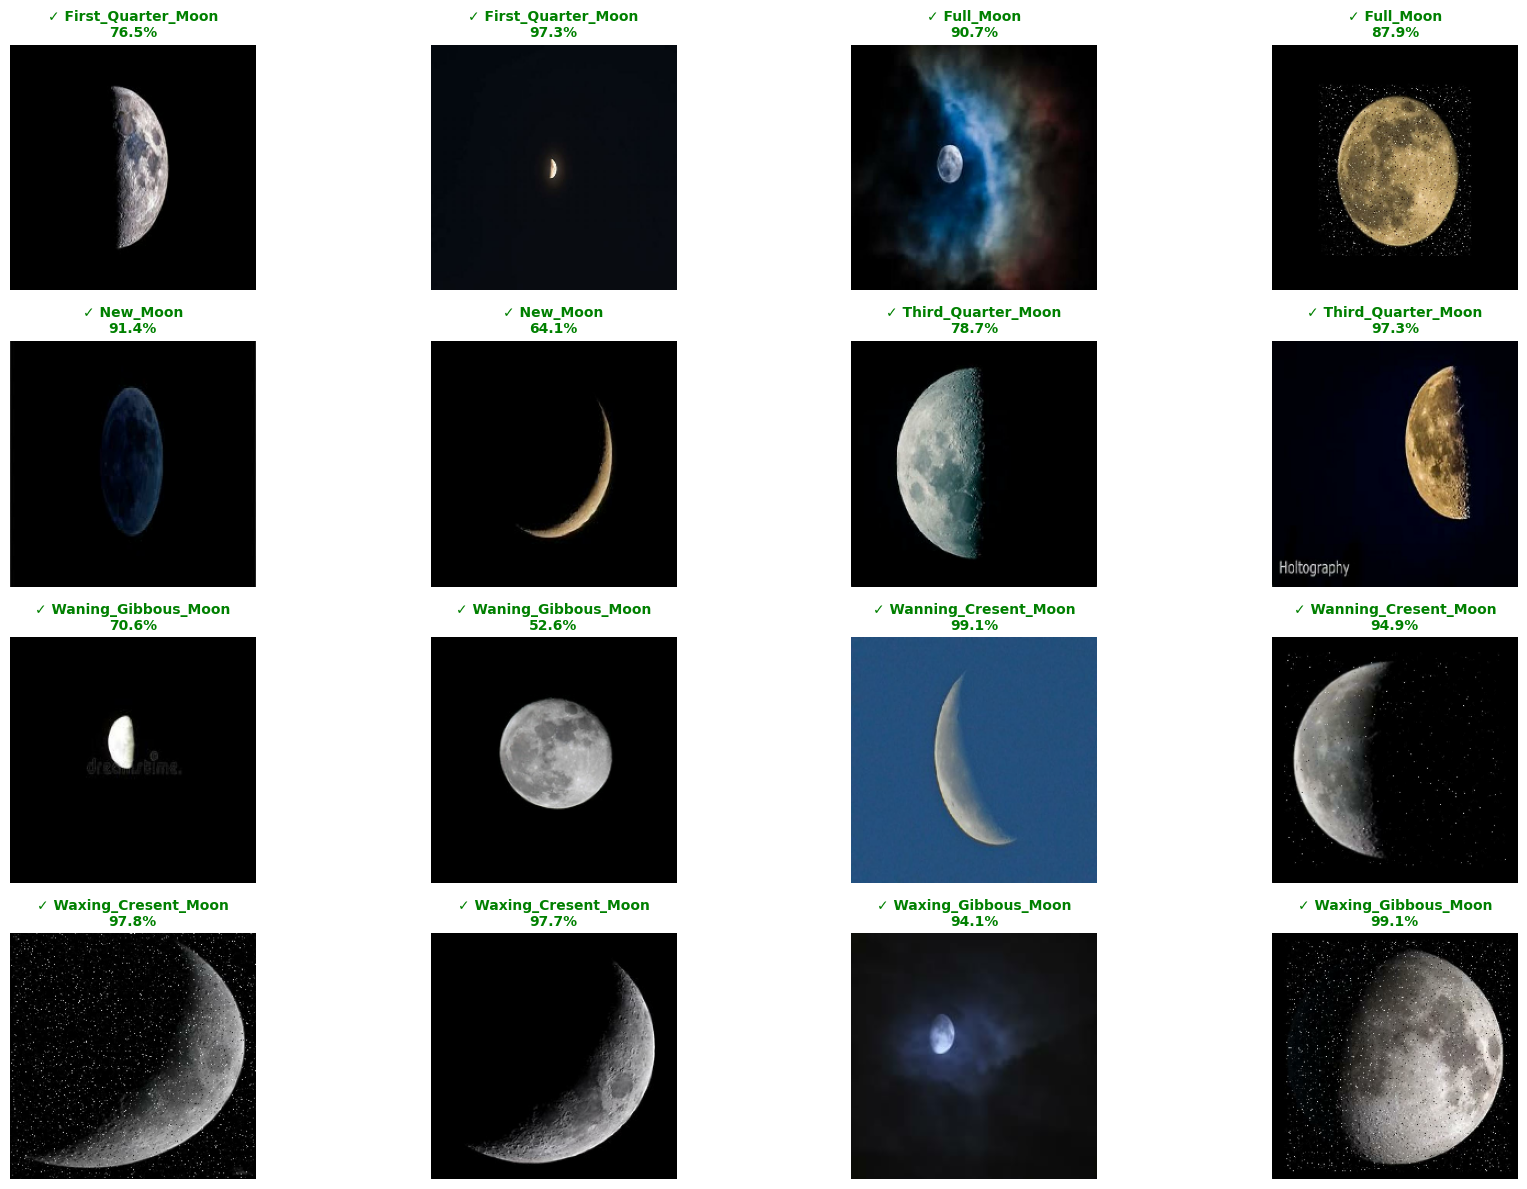


� Komposisi kelas pada grid:
   - First_Quarter_Moon: 2 contoh
   - Full_Moon: 2 contoh
   - New_Moon: 2 contoh
   - Third_Quarter_Moon: 2 contoh
   - Waning_Gibbous_Moon: 2 contoh
   - Wanning_Cresent_Moon: 2 contoh
   - Waxing_Cresent_Moon: 2 contoh
   - Waxing_Gibbous_Moon: 2 contoh

✅ Testing selesai dengan sampel yang lebih merata per kelas.


In [ ]:
print("\n" + "="*60)
print("🧪 TESTING INFERENCE DENGAN SAMPLING LEBIH BERAGAM")
print("="*60)

# Load model (best checkpoint)
best_model_path_p2 = os.path.join(OUTPUT_DIR, 'best_model_phase3.keras')
model = keras.models.load_model(best_model_path_p2)
print("✅ Model loaded: best_model_phase3.keras")

# Helper: denormalize MobileNetV2 preprocess_input untuk display
def denormalize_mobilenet_v2(img_batch):
    return tf.clip_by_value((img_batch + 1.0) * 127.5, 0.0, 255.0)

# Kumpulkan sampel yang mencakup banyak kelas dari beberapa batch test_ds
max_total_samples = 16  # tampilkan sampai 16 gambar
per_class_limit = 2     # upaya ambil max 2 contoh per kelas
class_to_indices = {cls: [] for cls in class_names}
collected_images = []
collected_labels = []

# Iterasi beberapa batch untuk mengumpulkan representasi tiap kelas
for images, labels in test_ds.take(10):  # ambil sampai 10 batch pertama
    label_indices = np.argmax(labels.numpy(), axis=1)
    for i in range(len(images)):
        cls_idx = int(label_indices[i])
        cls_name = class_names[cls_idx]
        # Batasi per kelas agar merata
        if len(class_to_indices[cls_name]) < per_class_limit:
            class_to_indices[cls_name].append(len(collected_images))
            collected_images.append(images[i])
            collected_labels.append(labels[i])
        # Hentikan jika sudah cukup total
        if len(collected_images) >= max_total_samples:
            break
    if len(collected_images) >= max_total_samples:
        break

# Jika masih kurang (mis. beberapa kelas tidak muncul di batch awal), isi dari batch berikutnya tanpa batasan kelas
if len(collected_images) < max_total_samples:
    for images, labels in test_ds.skip(10).take(10):
        for i in range(len(images)):
            collected_images.append(images[i])
            collected_labels.append(labels[i])
            if len(collected_images) >= max_total_samples:
                break
        if len(collected_images) >= max_total_samples:
            break

# Konversi ke tensor/batch
sample_images = tf.stack(collected_images, axis=0)
sample_true_labels = tf.stack(collected_labels, axis=0)

# Prediksi
preds = model.predict(sample_images, verbose=0)
pred_indices = np.argmax(preds, axis=1)
true_indices = np.argmax(sample_true_labels.numpy(), axis=1)

# Tampilkan grid
rows = 4
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
axes = axes.flatten()

print("\n📊 Predictions (lebih beragam kelas):")
for idx in range(len(sample_images)):
    img_disp = denormalize_mobilenet_v2(tf.expand_dims(sample_images[idx], 0))[0].numpy().astype(np.uint8)
    pred_idx = int(pred_indices[idx])
    true_idx = int(true_indices[idx])

    pred_class = class_names[pred_idx]
    true_class = class_names[true_idx]
    confidence = float(preds[idx][pred_idx])
    is_correct = pred_idx == true_idx

    axes[idx].imshow(img_disp)
    axes[idx].axis('off')

    color = 'green' if is_correct else 'red'
    marker = '✓' if is_correct else '✗'  # ganti glyph agar aman di font default

    title = f"{marker} {pred_class}\n{confidence*100:.1f}%"
    if not is_correct:
        title += f"\n(True: {true_class})"

    axes[idx].set_title(title, fontsize=10, color=color, fontweight='bold')

    print(f"{idx+1}. {'✅' if is_correct else '❌'}")
    print(f"   Predicted: {pred_class} ({confidence*100:.2f}%)")
    print(f"   True: {true_class}")

# Sembunyikan sisa axes jika kurang dari 16
for k in range(len(sample_images), rows*cols):
    axes[k].axis('off')

plt.tight_layout()
plt.savefig('test_predictions_diverse.png', dpi=200, bbox_inches='tight')
print("\n📊 Predictions saved: test_predictions_diverse.png")
plt.show()

# Ringkas distribusi kelas yang ditampilkan
shown_counts = {}
for idx in true_indices:
    cls = class_names[int(idx)]
    shown_counts[cls] = shown_counts.get(cls, 0) + 1
print("\n� Komposisi kelas pada grid:")
for cls in class_names:
    print(f"   - {cls}: {shown_counts.get(cls, 0)} contoh")

print("\n✅ Testing selesai dengan sampel yang lebih merata per kelas.")

In [ ]:
print("\n" + "="*70)
print("💾 SAVING MODELS")
print("="*70)

# Save model terbaik ke Drive
final_path = os.path.join(OUTPUT_DIR, 'model_moon_phase_3phase_final.keras')
model.save(final_path)
print(f"✅ Keras model : {final_path}")

# Convert ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

tflite_path = os.path.join(OUTPUT_DIR, 'model_moon_phase_3phase.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
tflite_size = os.path.getsize(tflite_path) / 1024 / 1024
print(f"✅ TFLite model : {tflite_path} ({tflite_size:.2f} MB)")

# Save class names
class_file = os.path.join(OUTPUT_DIR, 'class_names.txt')
with open(class_file, 'w') as f:
    for i, name in enumerate(class_names):
        f.write(f"{i},{name}\n")
print(f"✅ Class names  : {class_file}")
print("="*70)



💾 SAVING MODELS
✅ Keras model : /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/model_moon_phase_3phase_final.keras
Saved artifact at '/tmp/tmpimkzv2f_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  132194266424208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266425360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266425168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266424784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266425936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266424400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266425552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132194266425744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13219

In [ ]:
import os, shutil, glob, zipfile, datetime

assert 'OUTPUT_DIR' in globals()
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n" + "="*70)
print("🚚 BACKUP ARTEFAK KE GOOGLE DRIVE")
print("="*70)

artifact_candidates = [
    'best_model_phase1.keras',
    'best_model_phase2.keras',
    'best_model_phase3.keras',
    'model_moon_phase_3phase_final.keras',
    'model_moon_phase_3phase.tflite',
    'training_history_3phase.png',
    'confusion_matrix_clean.png',
    'test_predictions_diverse.png',
    'class_names.txt',
]

copied, skipped = [], []

def safe_copy(src, dst_dir):
    if not os.path.exists(src):
        skipped.append(src); print(f"⚠️  Not found: {src}"); return
    dst = os.path.join(dst_dir, os.path.basename(src))
    if os.path.abspath(src) == os.path.abspath(dst):
        skipped.append(src); print(f"ℹ️  Already in Drive: {src}"); return
    if os.path.exists(dst):
        skipped.append(src); print(f"ℹ️  Already exists: {dst}"); return
    shutil.copy2(src, dst)
    copied.append(dst); print(f"✅ Copied: {os.path.basename(src)}")

for f in artifact_candidates:
    safe_copy(f, OUTPUT_DIR)

ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
zip_path = os.path.join(OUTPUT_DIR, f"backup_3phase_{ts}.zip")
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(OUTPUT_DIR):
        fp = os.path.join(OUTPUT_DIR, fname)
        if os.path.isfile(fp) and any(fp.endswith(e) for e in ['.keras','.tflite','.png','.txt']):
            zf.write(fp, arcname=fname)

print(f"\n📦 ZIP: {zip_path}")
print(f"✅ Disalin: {len(copied)} | Diskip: {len(skipped)}")
print("✅ Backup selesai.")



🚚 BACKUP ARTEFAK KE GOOGLE DRIVE
⚠️  Not found: best_model_phase1.keras
⚠️  Not found: best_model_phase2.keras
⚠️  Not found: best_model_phase3.keras
⚠️  Not found: model_moon_phase_3phase_final.keras
⚠️  Not found: model_moon_phase_3phase.tflite
✅ Copied: training_history_3phase.png
✅ Copied: confusion_matrix_clean.png
⚠️  Not found: test_predictions_diverse.png
⚠️  Not found: class_names.txt

📦 ZIP: /content/drive/MyDrive/Colab Notebooks/Outputs/Moon6DatasetCombinedMobileNetV2/backup_3phase_20260522_222806.zip
✅ Disalin: 2 | Diskip: 7
✅ Backup selesai.


In [ ]:
print("\n" + "="*70)
print("📋 FINAL SUMMARY — MobileNetV2 3-Phase Fine-tuning")
print("="*70)

print(f"\n✅ Model Performance:")
print(f"   Phase 1 best val accuracy : {best_val_acc_p1*100:.2f}%")
print(f"   Phase 2 best val accuracy : {best_val_acc_p2*100:.2f}%")
print(f"   Phase 3 best val accuracy : {best_val_acc_p3*100:.2f}%")
print(f"   Test Accuracy             : {test_acc*100:.2f}%")

print(f"\n🔧 Konfigurasi:")
print(f"   Augmentasi Phase 1 & 2 : moderate (horizontal flip only)")
print(f"   Augmentasi Phase 3     : light")
print(f"   LR Phase 1             : 1e-3 (Cosine Annealing)")
print(f"   LR Phase 2             : 2e-5 (20 layers unfrozen)")
print(f"   LR Phase 3             : 1e-5 (70 layers unfrozen)")
print(f"   Dense head             : 256 neuron | Dropout: 0.20 + 0.15")
print(f"   L2 regularization      : 0.001")

print(f"\n💾 Files:")
print(f"   model_moon_phase_3phase_final.keras")
print(f"   model_moon_phase_3phase.tflite")
print(f"   training_history_3phase.png")
print(f"   confusion_matrix_clean.png")
print(f"   class_names.txt")

if test_acc >= 0.90:
    print(f"\n🎉 TARGET 90% TERCAPAI! Siap deploy ke Android.")
elif test_acc >= 0.85:
    print(f"\n✅ {test_acc*100:.1f}% — Pertimbangkan TTA saat inferensi di Android.")
else:
    print(f"\n💡 Saran: coba ensemble 2-3 model untuk mendorong ke 90%+")
print("="*70)



📋 FINAL SUMMARY — MobileNetV2 3-Phase Fine-tuning

✅ Model Performance:
   Phase 1 best val accuracy : 84.34%
   Phase 2 best val accuracy : 87.26%
   Phase 3 best val accuracy : 91.91%
   Test Accuracy             : 88.32%

🔧 Konfigurasi:
   Augmentasi Phase 1 & 2 : moderate (horizontal flip only)
   Augmentasi Phase 3     : light
   LR Phase 1             : 1e-3 (Cosine Annealing)
   LR Phase 2             : 2e-5 (20 layers unfrozen)
   LR Phase 3             : 1e-5 (70 layers unfrozen)
   Dense head             : 256 neuron | Dropout: 0.20 + 0.15
   L2 regularization      : 0.001

💾 Files:
   model_moon_phase_3phase_final.keras
   model_moon_phase_3phase.tflite
   training_history_3phase.png
   confusion_matrix_clean.png
   class_names.txt

✅ 88.3% — Pertimbangkan TTA saat inferensi di Android.
